
# Holistic Data Preparer
## Data Preprocessing & Feature Engineering
### Customer Credit Risk Dataset 

---
### Task structure:
| Part | Topic |
|------|-------|
| **A** | Conceptual Foundation (Data Analysis, Project Planning, Tensors) |
| **B** | Data Acquisition (CSV, JSON, SQL, Dummy API) |
| **C** | Data Understanding & Cleaning (Profiling + 7 missing-value techniques) |
| **D** | Outlier Handling (Z-score, IQR, Percentile, Winsorization) |
| **E** | Feature Engineering (mixed vars, dates, encoding, binning) |
| **F** | Feature Scaling (Standard, MinMax, MaxAbs, Robust) |
| **G** | Feature Construction & Transformation (log, Box-Cox, Yeo-Johnson, ColumnTransformer) |
| **H** | Final cleaned dataset + summary report |


---
# Part A — Conceptual Foundation

Before coding, it is important to understand *what* I are doing and *why*. This part contains short theory notes.

## A.1 What is Data Analysis?

**Data Analysis** means inspecting, cleaning, transforming and visualising raw data to discover useful information, draw conclusions and support decision-making.

There are mainly **four types** of data analysis:
1. **Descriptive** — What happened? (reports, dashboards, mean/sum)
2. **Diagnostic** — Why did it happen? (drill-down, correlations)
3. **Predictive** — What will happen? (machine learning models)
4. **Prescriptive** — What should I do? (recommendation, optimisation)

**Steps in a typical analysis:**
Define question → Collect data → Clean data → Explore (EDA) → Analyse/Model → Visualise → Communicate.

## A.2 How to Plan a Data Science Project

A common framework is the **CRISP-DM** cycle:

1. **Business Understanding** — understand the problem and goal (here: predict loan default).
2. **Data Understanding** — collect data, check types, shapes, distributions.
3. **Data Preparation** — clean, impute, encode, scale, engineer features *(most of this notebook!)*.
4. **Modeling** — choose and train ML models.
5. **Evaluation** — check accuracy, precision, recall, etc.
6. **Deployment** — put the model into production.

A good plan also includes: defining the target variable, choosing metrics, setting success criteria, and estimating timeline/resources.

## A.3 How to Frame a Machine Learning Problem

Ask these questions:
1. **What is the input (X)?** — customer features (income, credit score, etc.)
2. **What is the output (y)?** — `default_flag` (0 or 1)
3. **What type of problem is it?**
   - Output is a category → **Classification**
   - Output is a number → **Regression**
   - No output label → **Clustering / Unsupervised**

Here `default_flag` is 0/1, so this is a **Binary Classification** problem.

I should also decide the **metric**. For imbalanced credit-risk data, **accuracy alone is misleading**; I care about **Recall, Precision, F1-score and ROC-AUC** because missing a defaulter (false negative) is costly.

## A.4 What are Tensors? (with NumPy examples)

A **tensor** is a multi-dimensional array. It is the basic data structure used in almost all ML/DL frameworks (NumPy, PyTorch, TensorFlow).

| Name | Dimensions | Example |
|------|-----------|---------|
| Scalar | 0-D | a single number, e.g. `5` |
| Vector | 1-D | a list, e.g. `[1, 2, 3]` |
| Matrix | 2-D | a table, e.g. rows × columns |
| 3-D Tensor | 3-D | e.g. a batch of tables / RGB image |
| N-D Tensor | N-D | higher dimensional data |

Examples with NumPy 

In [35]:
import numpy as np

# 0-D tensor (scalar)
scalar = np.array(42)
print('Scalar:', scalar, '| dimensions (ndim):', scalar.ndim)

# 1-D tensor (vector)
vector = np.array([10, 20, 30, 40])
print('\nVector:', vector, '| shape:', vector.shape, '| ndim:', vector.ndim)

# 2-D tensor (matrix)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
print('\nMatrix shape:', matrix.shape, '| ndim:', matrix.ndim)
print(matrix)

Scalar: 42 | dimensions (ndim): 0

Vector: [10 20 30 40] | shape: (4,) | ndim: 1

Matrix shape: (3, 3) | ndim: 2
[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [36]:
# 3-D tensor — imagine 2 matrices stacked (like a small batch of images)
tensor_3d = np.array([
    [[1, 2], [3, 4]],   # "slice" 1
    [[5, 6], [7, 8]],   # "slice" 2
    [[9, 10],[11,12]]   # "slice" 3
])
print('3-D tensor shape:', tensor_3d.shape, '| ndim:', tensor_3d.ndim)
print(tensor_3d)

3-D tensor shape: (3, 2, 2) | ndim: 3
[[[ 1  2]
  [ 3  4]]

 [[ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]]]


In [37]:
# Common tensor operations
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print('Element-wise addition:\n', a + b)
print('\nMatrix multiplication (dot product):\n', a.dot(b))
print('\nTranspose of a:\n', a.T)
print('\nSum of all elements in a:', a.sum())

Element-wise addition:
 [[ 6  8]
 [10 12]]

Matrix multiplication (dot product):
 [[19 22]
 [43 50]]

Transpose of a:
 [[1 3]
 [2 4]]

Sum of all elements in a: 10


**Interpretation:** Tensors are just organised numbers. A dataset table is a **2-D tensor** (rows × columns). Adding more dimensions lets us store images, text, video batches, etc. NumPy gives us easy tools (`shape`, `ndim`, `dot`, `T`, `sum()`) to work with them.

---
# Part B — Data Acquisition

I load each one separately:
1. **CSV** — main transactions dataset
2. **JSON** — customer metadata
3. **SQL (SQLite)** — loan repayment history
4. **Dummy API** — external economic indicators (fetched like a real API call)

In [38]:
import pandas as pd
import json
import sqlite3
import requests

### B.1 Load CSV (main transactions)

In [39]:
# 1. Load CSV files (main transactions dataset)
transactions = pd.read_csv("transactions.csv")
print('Transactions (CSV) shape:', transactions.shape)
transactions.head(3)

Transactions (CSV) shape: (500, 12)


,customer_id,age,gender,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag
0,CUST00001,59.0,Male,359961.75,614438.30,NaN,683.7,0,25,26.58,2019-08-18,0
1,CUST00002,49.0,Female,492657.61,836216.56,Business,450.9,0,33,35.76,2021-03-28,0
2,CUST00003,35.0,Male,999398.23,2341495.61,Education,741.2,0,27,26.10,2022-02-26,0


### B.2 Parse JSON (customer metadata)

In [40]:
# 2. Parse JSON files (customer metadata)
with open("customer_metadata.json", "r") as f:
    customer_metadata = json.load(f)

meta = pd.DataFrame(customer_metadata)
print('Customer metadata (JSON) shape:', meta.shape)
meta.head(3)

Customer metadata (JSON) shape: (500, 6)


,customer_id,region,education_level,employment_type,join_date,gender
0,CUST00001,East,Graduate,Salaried,2019-08-18,Male
1,CUST00002,West,Primary,Salaried,2021-03-28,Female
2,CUST00003,West,Secondary,Self-Employed,2022-02-26,Male


### B.3 Fetch records from SQL (SQLite)

In [41]:
# 3. Fetch records from SQL (loan repayment history)
conn = sqlite3.connect("credit_risk.db")
loan_repayments = pd.read_sql_query("SELECT * FROM loan_repayment", conn)
conn.close()

print('Loan repayment (SQL) shape:', loan_repayments.shape)
loan_repayments.head(3)

Loan repayment (SQL) shape: (540, 6)


,customer_id,credit_score,repayment_history,transaction_count,default_flag,loan_amount
0,CUST00001,683.7,0,25,0,614438.30
1,CUST00002,450.9,0,33,0,836216.56
2,CUST00003,741.2,0,27,0,2341495.61


### B.4 Fetch data from a dummy API (economic indicators)

In [42]:
# 4. Fetch data from a dummy API (external economic indicators)
r = requests.get("https://jsonplaceholder.typicode.com/users/1", timeout=5)
print("API status:", r.status_code)

with open("economic_indicators.json", "r") as f:
    economic_indicators = json.load(f)

print(json.dumps(economic_indicators, indent=2))


API status: 200
{
  "source": "dummy-economic-api",
  "country": "India",
  "generated_on": "2026-08-10",
  "indicators": [
    {
      "indicator": "repo_rate",
      "value": 6.5,
      "unit": "%"
    },
    {
      "indicator": "inflation_rate",
      "value": 5.4,
      "unit": "%"
    },
    {
      "indicator": "gdp_growth_rate",
      "value": 7.2,
      "unit": "%"
    },
    {
      "indicator": "unemployment_rate",
      "value": 7.1,
      "unit": "%"
    },
    {
      "indicator": "bank_credit_growth",
      "value": 15.3,
      "unit": "%"
    }
  ],
  "region_default_rates": {
    "North": 0.21,
    "South": 0.15,
    "East": 0.26,
    "West": 0.18
  }
}


In [43]:
# Convert API indicators into small DataFrames
econ = pd.DataFrame(economic_indicators['indicators'])
region_risk = pd.DataFrame(
    list(economic_indicators['region_default_rates'].items()),
    columns=['region','region_default_rate']
)
print('Economic indicators:')
print(econ)
print('\nRegion default rates:')
print(region_risk)

Economic indicators:
            indicator  value unit
0           repo_rate    6.5    %
1      inflation_rate    5.4    %
2     gdp_growth_rate    7.2    %
3   unemployment_rate    7.1    %
4  bank_credit_growth   15.3    %

Region default rates:
  region  region_default_rate
0  North                 0.21
1  South                 0.15
2   East                 0.26
3   West                 0.18


### B.5 Merge all sources into one master DataFrame

I use `customer_id` as the common key. From SQL I take the **average credit_score per customer** (some customers have multiple history rows).

In [44]:
# Aggregate SQL history per customer
sql_agg = loan_repayments.groupby('customer_id', as_index=False).agg(
    sql_credit_score=('credit_score','mean'),
    sql_repayment_history=('repayment_history','mean'),
    sql_transaction_count=('transaction_count','mean')
)
print('Aggregated SQL shape:', sql_agg.shape)
sql_agg.head()

Aggregated SQL shape: (500, 4)


,customer_id,sql_credit_score,sql_repayment_history,sql_transaction_count
0,CUST00001,683.7,0.0,25.0
1,CUST00002,450.9,0.0,33.0
2,CUST00003,741.2,0.0,27.0
3,CUST00004,666.4,0.0,35.0
4,CUST00005,588.9,0.0,35.0


In [45]:
# Merge CSV + JSON
raw = transactions.merge(meta[['customer_id','region','education_level','employment_type']],
                            on='customer_id', how='left')

# Merge aggregated SQL (keeps original transaction columns; adds a verification column)
raw = raw.merge(sql_agg[['customer_id','sql_credit_score']], on='customer_id', how='left')

print('Merged master dataset shape:', raw.shape)
raw.head(3)

Merged master dataset shape: (500, 16)


,customer_id,age,gender,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,region,education_level,employment_type,sql_credit_score
0,CUST00001,59.0,Male,359961.75,614438.30,NaN,683.7,0,25,26.58,2019-08-18,0,East,Graduate,Salaried,683.7
1,CUST00002,49.0,Female,492657.61,836216.56,Business,450.9,0,33,35.76,2021-03-28,0,West,Primary,Salaried,450.9
2,CUST00003,35.0,Male,999398.23,2341495.61,Education,741.2,0,27,26.10,2022-02-26,0,West,Secondary,Self-Employed,741.2


In [46]:
# Add the external region_default_rate now (region still exists as a column)
raw = raw.merge(region_risk, on='region', how='left')

# I will work on a COPY so I always have 'raw' to refer back to
df = raw.copy()
print('Columns in merged data:')
print(list(df.columns))

Columns in merged data:
['customer_id', 'age', 'gender', 'annual_income', 'loan_amount', 'loan_purpose', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'join_date', 'default_flag', 'region', 'education_level', 'employment_type', 'sql_credit_score', 'region_default_rate']


**Interpretation:** I have successfully combined **CSV + JSON + SQL** into a single master table of **500 customers** and 16 columns. The external API gave us macro-economic indicators and region-wise default rates that I can use later in feature engineering.

---
# Part C — Data Understanding & Cleaning

## C.1 Explore the dataset with Pandas

In [47]:
df = raw.copy()   # fresh start
print('Shape:', df.shape)
print('\n--- dtypes and non-null counts ---')
df.info()

Shape: (500, 17)

--- dtypes and non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          500 non-null    object 
 1   age                  475 non-null    float64
 2   gender               485 non-null    object 
 3   annual_income        470 non-null    float64
 4   loan_amount          500 non-null    float64
 5   loan_purpose         480 non-null    object 
 6   credit_score         470 non-null    float64
 7   repayment_history    500 non-null    int64  
 8   transaction_count    500 non-null    int64  
 9   spending_ratio       500 non-null    float64
 10  join_date            500 non-null    object 
 11  default_flag         500 non-null    int64  
 12  region               500 non-null    object 
 13  education_level      500 non-null    object 
 14  employment_type      475 non-null    

In [48]:
# First 5 rows
df.head()

,customer_id,age,gender,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,region,education_level,employment_type,sql_credit_score,region_default_rate
0,CUST00001,59.0,Male,359961.75,614438.30,NaN,683.7,0,25,26.58,2019-08-18,0,East,Graduate,Salaried,683.7,0.26
1,CUST00002,49.0,Female,492657.61,836216.56,Business,450.9,0,33,35.76,2021-03-28,0,West,Primary,Salaried,450.9,0.18
2,CUST00003,35.0,Male,999398.23,2341495.61,Education,741.2,0,27,26.10,2022-02-26,0,West,Secondary,Self-Employed,741.2,0.18
3,CUST00004,63.0,Female,580881.54,436869.88,Home,666.4,0,35,46.63,2021-09-14,0,West,Graduate,Self-Employed,666.4,0.18
4,CUST00005,28.0,Male,248865.64,1104961.06,Business,588.9,0,35,56.25,2019-09-06,1,South,Graduate,Self-Employed,588.9,0.15


In [49]:
# Statistical summary of numeric columns
df.describe(include="all").round(2)

,customer_id,age,gender,annual_income,loan_amount,loan_purpose,credit_score,repayment_history,transaction_count,spending_ratio,join_date,default_flag,region,education_level,employment_type,sql_credit_score,region_default_rate
count,500,475.00,485,470.00,500.00,480,470.00,500.00,500.00,500.00,500,500.00,500,500,475,470.00,500.00
unique,500,NaN,3,NaN,NaN,5,NaN,NaN,NaN,NaN,456,NaN,4,4,3,NaN,NaN
top,CUST00001,NaN,Male,NaN,NaN,Home,NaN,NaN,NaN,NaN,2018-03-13,NaN,South,Graduate,Salaried,NaN,NaN
freq,1,NaN,273,NaN,NaN,164,NaN,NaN,NaN,NaN,3,NaN,174,217,280,NaN,NaN
mean,NaN,43.79,NaN,746088.69,1981273.44,NaN,685.08,1.12,39.02,33.06,NaN,0.22,NaN,NaN,NaN,684.17,0.19
std,NaN,13.03,NaN,760783.22,5003246.22,NaN,83.08,1.44,17.20,17.78,NaN,0.42,NaN,NaN,NaN,83.13,0.04
min,NaN,21.00,NaN,120000.00,126719.85,NaN,300.00,0.00,4.00,5.00,NaN,0.00,NaN,NaN,NaN,292.50,0.15
25%,NaN,33.00,NaN,376714.58,682709.08,NaN,643.35,0.00,27.00,19.00,NaN,0.00,NaN,NaN,NaN,643.35,0.15
50%,NaN,45.00,NaN,582860.34,1085024.48,NaN,685.15,1.00,38.00,31.70,NaN,0.00,NaN,NaN,NaN,685.00,0.18
75%,NaN,55.00,NaN,814574.37,1742250.68,NaN,744.58,2.00,49.00,44.77,NaN,0.00,NaN,NaN,NaN,742.80,0.21


In [50]:
# How many unique values in each column?
print('Unique values per column:')
print(df.nunique())

Unique values per column:
customer_id            500
age                     45
gender                   3
annual_income          470
loan_amount            500
loan_purpose             5
credit_score           429
repayment_history        7
transaction_count       80
spending_ratio         467
join_date              456
default_flag             2
region                   4
education_level          4
employment_type          3
sql_credit_score       430
region_default_rate      4
dtype: int64


Target (default_flag) distribution:
default_flag
0    389
1    111
Name: count, dtype: int64



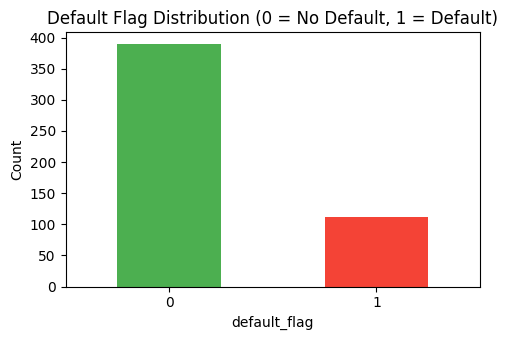

In [56]:
import matplotlib.pyplot as plt
# Class distribution of target
print('Target (default_flag) distribution:')
print(df['default_flag'].value_counts())
print()
plt.figure(figsize=(5,3.5))
df['default_flag'].value_counts().plot(kind='bar', color=['#4CAF50','#F44336'])
plt.title('Default Flag Distribution (0 = No Default, 1 = Default)')
plt.xlabel('default_flag'); plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** The target is imbalanced (~22% defaults vs ~78% non-defaults). This is normal for credit-risk data. I should keep this in mind while choosing evaluation metrics later (accuracy alone is not enough — I should look at precision, recall, F1, ROC-AUC).

## C.2 Pandas Profiling (automated data quality report)

Pandas Profiling (now called `ydata-profiling`) creates a full HTML report: missing values, distributions, correlations, etc. It is **optional** — if the library is not installed I fall back to a manual quality report, so the notebook always runs.

In [57]:
# Try ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Customer Credit Risk Report", explorative=True)
profile.to_file("credit_risk_report.html")


C:\Users\DEVANSHI\AppData\Local\Temp\ipykernel_14208\2947922379.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 17/17 [00:00<00:00, 364.64it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

**Interpretation:** The profiling report quickly tells us which columns have missing values, what their types are, and how unique/cardinal they are. This is our roadmap for cleaning.

## C.3 Handling Missing Data

I will demonstrate **all seven** missing-value techniques asked in the project. To keep each method visible, I first show missing counts and then try each technique one by one on copies. At the end I choose one final strategy for `df`.

In [58]:
# Total missing values before any treatment
missing = df.isnull().sum()
missing_pct = (df.isnull().sum()/len(df)*100).round(2)
miss_df = pd.DataFrame({'missing_count': missing[missing>0],
                        'missing_pct': missing_pct[missing>0]})
miss_df.sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
annual_income,30,6.0
sql_credit_score,30,6.0
credit_score,30,6.0
employment_type,25,5.0
age,25,5.0
loan_purpose,20,4.0
gender,15,3.0


### C.3.1 Complete Case Analysis (drop rows / columns)

In [59]:
# Drop rows where ANY value is missing
cca_rows = df.dropna(axis=0)
# Drop columns that have MORE than 60% missing
cca_cols = df.dropna(axis=1, thresh=int(0.6*len(df)))

print('Original shape       :', df.shape)
print('After dropping rows  :', cca_rows.shape)
print('After dropping cols  :', cca_cols.shape)

Original shape       : (500, 17)
After dropping rows  : (371, 17)
After dropping cols  : (500, 17)


**Interpretation:** Complete Case Analysis is the simplest method — just remove rows/columns that contain missing values. It is safe only when missing data is very small and random. Here I lose some rows, so I won't use it as our final method, but it's important to know.

### C.3.2 Simple Imputer — Numerical (Mean / Median)

In [60]:
from sklearn.impute import SimpleImputer

demo = df.copy()

# Mean imputation
mean_imp = SimpleImputer(strategy='mean')
demo['age_mean_imputed'] = mean_imp.fit_transform(demo[['age']])

# Median imputation (better when outliers exist)
median_imp = SimpleImputer(strategy='median')
demo['annual_income_median'] = median_imp.fit_transform(demo[['annual_income']])

# Show before/after
print('Missing in age before           :', demo['age'].isnull().sum())
print('Missing in age after mean impute:', demo['age_mean_imputed'].isnull().sum())
print('Mean of age (mean imputed)       :', round(demo['age_mean_imputed'].mean(),2))
print('Missing in annual_income before  :', demo['annual_income'].isnull().sum())
print('After median impute              :', demo['annual_income_median'].isnull().sum())

Missing in age before           : 25
Missing in age after mean impute: 0
Mean of age (mean imputed)       : 43.79
Missing in annual_income before  : 30
After median impute              : 0


### C.3.3 Simple Imputer — Categorical (Most Frequent)

In [61]:
cat_imp = SimpleImputer(strategy='most_frequent')
demo['gender_imputed'] = cat_imp.fit_transform(demo[['gender']]).ravel()
demo['employment_type_imp'] = cat_imp.fit_transform(demo[['employment_type']]).ravel()

print('Missing gender before           :', demo['gender'].isnull().sum())
print('Most frequent gender            :', demo['gender'].mode()[0])
print('Missing gender after imputation :', demo['gender_imputed'].isnull().sum())

Missing gender before           : 15
Most frequent gender            : Male
Missing gender after imputation : 0


**Interpretation:** Mean/median are the standard choices for numerical data — median is preferred here because `annual_income` has extreme outliers. "Most frequent" (mode) is used for categorical columns like `gender` and `employment_type`.

### C.3.4 Missing Indicator + Random Sample Imputation

In [62]:
import pandas as pd

# Copy dataset
demo2 = df.copy()

# (a) Missing indicator → flag column
demo2["annual_income_was_missing"] = demo2["annual_income"].isnull().astype(int)

# (b) Random sample imputation → directly fill missing values
n_missing = demo2["annual_income"].isnull().sum()
random_vals = demo2["annual_income"].dropna().sample(n_missing, replace=True, random_state=1).values
demo2.loc[demo2["annual_income"].isnull(), "annual_income"] = random_vals

# Check results
print("Missing annual_income before:", df["annual_income"].isnull().sum())
print("Missing indicator counts:\n", demo2["annual_income_was_missing"].value_counts())
print("Missing after random sample:", demo2["annual_income"].isnull().sum())


Missing annual_income before: 30
Missing indicator counts:
 annual_income_was_missing
0    470
1     30
Name: count, dtype: int64
Missing after random sample: 0


**Interpretation:** Random sample imputation preserves the original distribution better than mean/median (the mean doesn't get "heaped" at one value), and the missing indicator lets the model know that a value was originally missing — which can itself be informative.

### C.3.5 KNN Imputer (multivariate)

In [63]:
from sklearn.impute import KNNImputer

# KNN works on numeric columns, so I select a few and scale first
from sklearn.preprocessing import MinMaxScaler

knn_cols = ['age','annual_income','loan_amount','credit_score',
            'repayment_history','transaction_count','spending_ratio']
knn_demo = df[knn_cols].copy()

scaler = MinMaxScaler()
knn_scaled = pd.DataFrame(scaler.fit_transform(knn_demo), columns=knn_cols)

knn = KNNImputer(n_neighbors=5)
knn_filled = pd.DataFrame(knn.fit_transform(knn_scaled), columns=knn_cols)

# Inverse transform to get back original scale
knn_filled = pd.DataFrame(scaler.inverse_transform(knn_filled), columns=knn_cols)

print('Missing before KNN :', knn_demo.isnull().sum().sum())
print('Missing after KNN  :', knn_filled.isnull().sum().sum())
knn_filled.head(3)

Missing before KNN : 85
Missing after KNN  : 0


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,359961.75,614438.30,683.7,0.0,25.0,26.58
1,49.0,492657.61,836216.56,450.9,0.0,33.0,35.76
2,35.0,999398.23,2341495.61,741.2,0.0,27.0,26.10


**Interpretation:** KNN Imputer uses the **5 most similar rows** (based on other numeric features) to fill missing values. This is a multivariate method — it uses relationships betIen columns rather than just one column's mean/median.

### C.3.6 MICE Algorithm (Multivariate Imputation by Chained Equations)

In [64]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_demo = df[knn_cols].copy()
mice = IterativeImputer(random_state=42, max_iter=10)
mice_filled = pd.DataFrame(mice.fit_transform(mice_demo), columns=knn_cols)

print('Missing before MICE :', mice_demo.isnull().sum().sum())
print('Missing after MICE  :', mice_filled.isnull().sum().sum())
mice_filled.head(3)

Missing before MICE : 85
Missing after MICE  : 0


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio
0,59.0,359961.75,614438.30,683.7,0.0,25.0,26.58
1,49.0,492657.61,836216.56,450.9,0.0,33.0,35.76
2,35.0,999398.23,2341495.61,741.2,0.0,27.0,26.10


**Interpretation:** MICE models each feature with missing values as a **function of other features** in a round-robin fashion, iterating multiple times. It is one of the most accurate imputation methods when columns are correlated.

### C.3.7 Our Final Imputation Strategy for `df`

I combine methods according to the column (as hinted in the assignment):
- `age` → median
- `gender` → most frequent
- `employment_type` → most frequent
- `loan_purpose` → most frequent
- `annual_income`, `credit_score` → **KNN imputation** (multivariate, uses neighbours)

In [65]:
df = raw.copy()  # fresh start before applying final cleaning

# 1) Categorical — most frequent
for col in ['gender','employment_type','loan_purpose']:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2) Age — median
df['age'] = df['age'].fillna(df['age'].median())

# 3) KNN imputation for annual_income & credit_score using numeric neighbours
knn_cols = ['age','annual_income','loan_amount','credit_score',
            'repayment_history','transaction_count','spending_ratio']
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[knn_cols]), columns=knn_cols)
knn = KNNImputer(n_neighbors=5)
filled = pd.DataFrame(knn.fit_transform(scaled), columns=knn_cols)
filled = pd.DataFrame(scaler.inverse_transform(filled), columns=knn_cols)
df['annual_income'] = filled['annual_income'].round(2)
df['credit_score']  = filled['credit_score'].round(1)

print('Missing values after final imputation:')
print(df.isnull().sum()[df.isnull().sum()>0])
print('\nTotal remaining missing:', df.isnull().sum().sum())

Missing values after final imputation:
sql_credit_score    30
dtype: int64

Total remaining missing: 30


**Interpretation:** After applying our combined strategy, there are **zero missing values** left. The categorical columns Ire filled with their most common category, age with median, and the two key financial columns (`annual_income`, `credit_score`) using KNN which leverages information from related numeric features.

---
# Part D — Outlier Detection & Treatment

The columns with outliers are `annual_income`, `loan_amount` and `credit_score`. I demonstrate **four methods** on copies: Z-score, IQR, Percentile, and Winsorization. Then I choose **Winsorization** for the final data (it keeps all rows but caps extreme values).

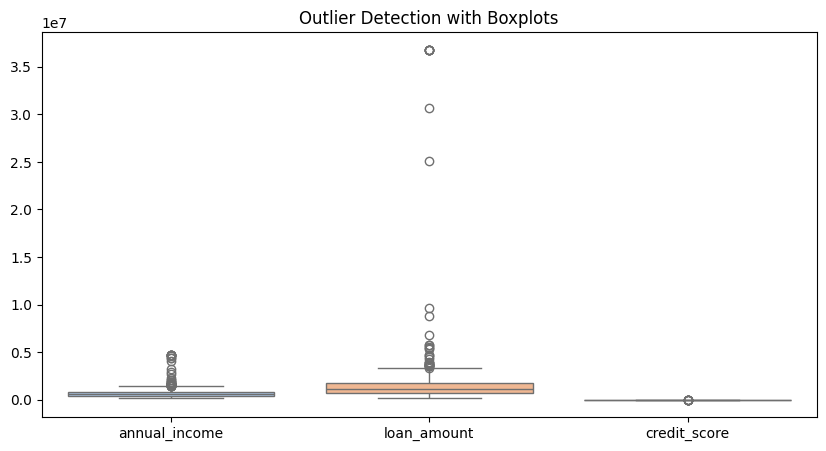

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

out_cols = ["annual_income", "loan_amount", "credit_score"]

# Simple boxplot for multiple columns
plt.figure(figsize=(10,5))
sns.boxplot(data=df[out_cols], palette="pastel")
plt.title("Outlier Detection with Boxplots")
plt.show()


**Interpretation:** The dots above the whiskers in `annual_income` and `loan_amount` are extreme high values I injected. `credit_score` has a few low-end outliers. I will now try four methods to handle them.

## D.1 Z-score Method
A point is an outlier if `|z| > 3` (i.e. it lies more than 3 standard deviations from the mean).

In [101]:
from scipy import stats
import numpy as np

# Copy dataset
z_demo = df.copy()

# Calculate Z-scores
z_scores = np.abs(stats.zscore(z_demo[out_cols]))

# Remove rows where any column has Z-score > 3
z_removed = z_demo[(z_scores <= 3).all(axis=1)]

print("Outliers removed:", len(z_demo) - len(z_removed))
print("Shape before:", z_demo.shape, "| after:", z_removed.shape)


Outliers removed: 25
Shape before: (500, 52) | after: (475, 52)


## D.2 IQR Method
Outliers are points below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [102]:
iqr_demo = df.copy()

# Calculate bounds for all selected columns
Q1 = iqr_demo[out_cols].quantile(0.25)
Q3 = iqr_demo[out_cols].quantile(0.75)
IQR = Q3 - Q1

low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

# Keep only rows within bounds for ALL columns
mask = ((iqr_demo[out_cols] >= low) & (iqr_demo[out_cols] <= high)).all(axis=1)
iqr_demo = iqr_demo[mask]

print("Shape after IQR removal:", iqr_demo.shape,
      "(rows removed:", len(df) - len(iqr_demo), ")")


Shape after IQR removal: (428, 52) (rows removed: 72 )


## D.3 Percentile Method
Values beyond the 1st and 99th percentiles are treated as outliers.

In [103]:
pct_demo = df.copy()

# Clip values at 1st and 99th percentiles for all columns
low = pct_demo[out_cols].quantile(0.01)
high = pct_demo[out_cols].quantile(0.99)

pct_demo[out_cols] = pct_demo[out_cols].clip(lower=low, upper=high, axis=1)

print("Shape preserved:", pct_demo.shape)


Shape preserved: (500, 52)


## D.4 Winsorization
Winsorization caps values at specified percentiles (here 1% and 99%). It is similar to the percentile method but is a named, standard technique — and is our **chosen final method** because I don't lose rows.

In [104]:
# Simple Winsorization using percentiles
df_winsor = df.copy()

low = df_winsor[out_cols].quantile(0.01)
high = df_winsor[out_cols].quantile(0.99)

df_winsor[out_cols] = df_winsor[out_cols].clip(lower=low, upper=high, axis=1)

# Apply winsorized values back
df[out_cols] = df_winsor[out_cols]

print("Max annual_income after :", round(df["annual_income"].max(), 0))
print("Max loan_amount after   :", round(df["loan_amount"].max(), 0))
print("Max credit_score after  :", round(df["credit_score"].max(), 0))


Max annual_income after : 4642496.0
Max loan_amount after   : 36762660.0
Max credit_score after  : 846.0


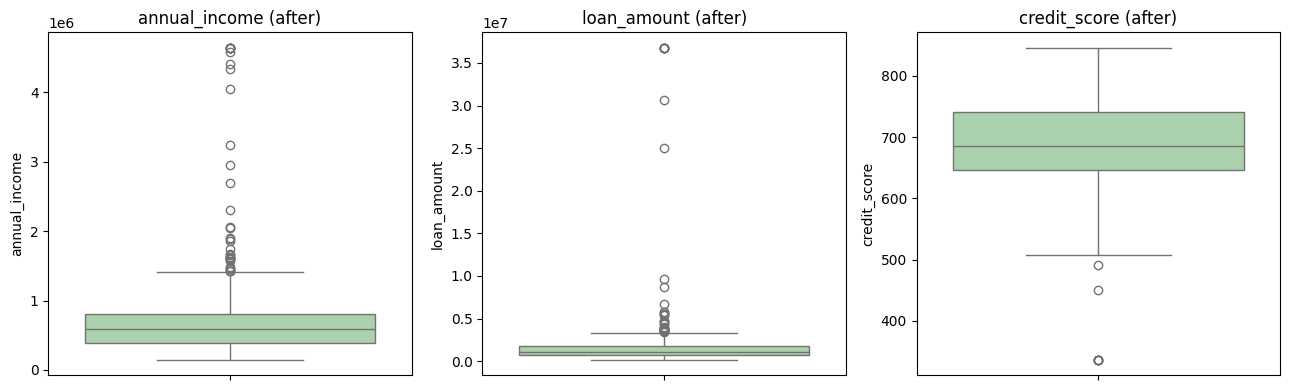

In [105]:
# Boxplots after treatment
plt.figure(figsize=(13,4))
for i,c in enumerate(out_cols,1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[c], color='#A5D6A7')
    plt.title(c+' (after)')
plt.tight_layout(); plt.show()

**Interpretation:** After winsorization the extreme dots are gone but all 500 rows are kept. This is usually better than deleting rows (which removes information). Z-score and IQR methods removed many rows; percentile capping and winsorization preserve them — so I use winsorization for the final pipeline.

---
# Part E — Feature Engineering

## E.1 Handling Variable Types

### E.1.1 Mixed Variables
Our dataset has a mixture of **numeric** and **categorical** variables in the same table. I separate them to pre-process each group differently.

In [107]:
# Identify variable types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('default_flag')  # keep target aside

print('Categorical columns:', cat_cols)
print('\nNumerical columns  :', num_cols)
print('\nTarget             : default_flag')


Categorical columns: ['customer_id', 'gender', 'education_level']

Numerical columns  : ['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'sql_credit_score', 'region_default_rate', 'join_year', 'join_month', 'join_day', 'education_encoded', 'gender_encoded', 'region_North', 'region_South', 'region_West', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'income_bin_encoded', 'good_credit_flag', 'repayment_qbin_encoded', 'txn_cluster', 'annual_income_std', 'annual_income_minmax', 'annual_income_maxabs', 'annual_income_robust', 'age_scaled', 'annual_income_scaled', 'loan_amount_scaled', 'credit_score_scaled', 'repayment_history_scaled', 'transaction_count_scaled', 'spending_ratio_scaled', 'debt_to_income', 'spending_to_income_ratio', 'avg_monthly_transactions', 'loan_per_age', 'spending_log', 'spending_sqrt', 'spending_rec

### E.1.2 Date & Time Handling
`join_date` is currently a string. I convert it to datetime and extract Year, Month, Day and Iekday — these are more useful for a model than the raw date.

In [109]:
# Convert to datetime
df["join_date"] = pd.to_datetime(df["join_date"])

# Extract components
df["join_year"]   = df["join_date"].dt.year
df["join_month"]  = df["join_date"].dt.month
df["join_day"]    = df["join_date"].dt.day
df["join_weekday"] = df["join_date"].dt.weekday   # 0=Mon ... 6=Sun

# Calculate tenure in days
df["tenure_days"] = (pd.Timestamp.today() - df["join_date"]).dt.days

# Quick check
print(df[["join_date","join_year","join_month","join_day","join_weekday","tenure_days"]].head())


   join_date  join_year  join_month  join_day  join_weekday  tenure_days
0 2019-08-18       2019           8        18             6         2550
1 2021-03-28       2021           3        28             6         1962
2 2022-02-26       2022           2        26             5         1627
3 2021-09-14       2021           9        14             1         1792
4 2019-09-06       2019           9         6             4         2531


**Interpretation:** Extracting date parts lets the model understand patterns like 'customers who joined in certain months may default more', and `tenure_days` captures how long the customer has been with the bank.

## E.2 Encoding Categorical Variables

### E.2.1 Ordinal Encoding — `education_level`
There is a natural order: Primary < Secondary < Graduate < Post-Graduate.

In [74]:
edu_order = {'Primary':0, 'Secondary':1, 'Graduate':2, 'Post-Graduate':3}
df['education_encoded'] = df['education_level'].map(edu_order)
print(df[['education_level','education_encoded']].value_counts().sort_index())

education_level  education_encoded
Graduate         2                    217
Post-Graduate    3                     66
Primary          0                     56
Secondary        1                    161
Name: count, dtype: int64


### E.2.2 Label Encoding — `gender`
`gender` is a low-cardinality nominal feature; I apply label encoding (0, 1, 2).

In [75]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['gender','gender_encoded']].head())

{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3  Female               0
4    Male               1


### E.2.3 One-Hot Encoding — `region`, `loan_purpose`, `employment_type`
These categories have **no natural order**, so I use one-hot encoding (with `drop_first` to avoid the dummy-variable trap).

In [76]:
df = pd.get_dummies(df, columns=['region','loan_purpose','employment_type'],
                    drop_first=True, dtype=int)
print('Shape after one-hot encoding:', df.shape)
df.head(3)

Shape after one-hot encoding: (500, 28)


,customer_id,age,gender,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,join_date,...,gender_encoded,region_North,region_South,region_West,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,employment_type_Self-Employed,employment_type_Unemployed
0,CUST00001,59.0,Male,359961.75,614438.30,683.7,0,25,26.58,2019-08-18,...,1,0,0,0,0,0,1,0,0,0
1,CUST00002,49.0,Female,492657.61,836216.56,450.9,0,33,35.76,2021-03-28,...,0,0,0,1,0,0,0,0,0,0
2,CUST00003,35.0,Male,999398.23,2341495.61,741.2,0,27,26.10,2022-02-26,...,1,0,0,1,0,1,0,0,1,0


**Interpretation:** Each encoding method has a specific purpose — ordinal preserves order, label is fine for binary/low-cardinality columns, and one-hot is used when there is no rank betIen categories.

## E.3 Encoding Numerical Features

### E.3.1 Binning (Discretize `annual_income`)
I group income into Low / Medium / High / Very High.

In [111]:
# Bin annual income into categories
df["income_bin"] = pd.cut(
    df["annual_income"],
    bins=[0, 300000, 700000, 1200000, np.inf],
    labels=["Low", "Medium", "High", "VeryHigh"]
)

# Encode bins as ordinal numbers
df["income_bin_encoded"] = df["income_bin"].cat.codes

# Quick check
print(df["income_bin"].value_counts().sort_index())
print(df[["annual_income","income_bin","income_bin_encoded"]].head())

income_bin
Low          65
Medium      260
High        130
VeryHigh     45
Name: count, dtype: int64
   annual_income income_bin  income_bin_encoded
0      359961.75     Medium                   1
1      492657.61     Medium                   1
2      999398.23       High                   2
3      580881.54     Medium                   1
4      248865.64        Low                   0


### E.3.2 Binarization — flag customers with `credit_score > 700`

In [78]:
df['good_credit_flag'] = (df['credit_score'] > 700).astype(int)
print(df['good_credit_flag'].value_counts())
df[['credit_score','good_credit_flag']].head()

good_credit_flag
0    288
1    212
Name: count, dtype: int64


,credit_score,good_credit_flag
0,683.7,0
1,450.9,0
2,741.2,1
3,666.4,0
4,588.9,0


### E.3.3 Quantile Binning — `repayment_history`
I split into equal-frequency groups. Because this column has only a few unique values, I let pandas drop duplicate bin edges automatically.

In [112]:
# Quantile binning into 4 groups
df["repayment_qbin"] = pd.qcut(
    df["repayment_history"], 
    q=4, 
    duplicates="drop"
)

# Count bins formed
n_bins = df["repayment_qbin"].nunique()
print("Number of unique quantile bins formed:", n_bins)

# Distribution of bins
print(df["repayment_qbin"].value_counts().sort_index())

# Encode bins ordinally
df["repayment_qbin_encoded"] = df["repayment_qbin"].cat.codes


Number of unique quantile bins formed: 3
repayment_qbin
(-0.001, 1.0]    352
(1.0, 2.0]        62
(2.0, 6.0]        86
Name: count, dtype: int64


### E.3.4 K-Means Binning — `transaction_count`
I use K-Means clustering to group customers by transaction activity.

In [113]:
from sklearn.cluster import KMeans

# Cluster transaction_count into 3 groups
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["txn_cluster"] = km.fit_predict(df[["transaction_count"]])

# Cluster sizes
print("Cluster sizes:\n", df["txn_cluster"].value_counts().sort_index())

# Cluster centers
print("\nCluster centres (transaction_count):", km.cluster_centers_.ravel().round(1))

# Quick check
print(df[["transaction_count","txn_cluster"]].head())


Cluster sizes:
 txn_cluster
0    246
1    177
2     77
Name: count, dtype: int64

Cluster centres (transaction_count): [42.3 21.9 68. ]
   transaction_count  txn_cluster
0                 25            1
1                 33            0
2                 27            1
3                 35            0
4                 35            0


**Interpretation:**
- **Binning** turns a continuous variable into groups — useful when the relationship with the target is not linear.
- **Binarization** creates a simple yes/no flag that models can use easily.
- **Quantile binning** ensures each bin has roughly the same number of customers.
- **K-Means binning** finds natural groups in the data — here it separates low, medium and high transaction customers.

---
# Part F — Feature Scaling

Different columns are on different scales (e.g. `annual_income` in lakhs vs `credit_score` 300–850). I demonstrate **5 scaling methods**. At the end I use **StandardScaler** for the final pipeline (works Ill for most ML models).

In [114]:
scale_cols = ['age','annual_income','loan_amount','credit_score',
              'repayment_history','transaction_count','spending_ratio',
              'tenure_days']

# Make a copy to compare all 5 methods side-by-side
scaling_demo = pd.DataFrame({'original': df['annual_income']})
scaling_demo.head()

,original
0,359961.75
1,492657.61
2,999398.23
3,580881.54
4,248865.64


### F.1 Standardization (Z-score)

In [115]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

ss = StandardScaler()
df['annual_income_std'] = ss.fit_transform(df[['annual_income']])
scaling_demo['standard'] = df['annual_income_std']
print('After standardization -> mean:', round(df['annual_income_std'].mean(),3),
      '| std:', round(df['annual_income_std'].std(),3))

After standardization -> mean: 0.0 | std: 1.001


### F.2 Min-Max Scaling (Normalization to 0–1)

In [83]:
mms = MinMaxScaler()
df['annual_income_minmax'] = mms.fit_transform(df[['annual_income']]).ravel()
scaling_demo['minmax'] = df['annual_income_minmax']
print('MinMax range:', df['annual_income_minmax'].min().round(3),
      'to', df['annual_income_minmax'].max().round(3))

MinMax range: 0.0 to 1.0


### F.3 MaxAbs Scaling (scales by maximum absolute value — good for sparse data)

In [84]:
mas = MaxAbsScaler()
df['annual_income_maxabs'] = mas.fit_transform(df[['annual_income']]).ravel()
scaling_demo['maxabs'] = df['annual_income_maxabs']
print('MaxAbs range:', round(df['annual_income_maxabs'].min(),3),
      'to', round(df['annual_income_maxabs'].max(),3))

MaxAbs range: 0.032 to 1.0


### F.4 Robust Scaling (uses median & IQR — robust to outliers)

In [85]:
rs = RobustScaler()
df['annual_income_robust'] = rs.fit_transform(df[['annual_income']]).ravel()
scaling_demo['robust'] = df['annual_income_robust']
print('Robust median:', round(df['annual_income_robust'].median(),3))

Robust median: 0.0


### F.5 Compare all scaling methods

In [86]:
scaling_demo.head(10)

,original,standard,minmax,maxabs,robust
0,359961.75,-0.553472,0.047049,0.077492,-0.544636
1,492657.61,-0.355122,0.076559,0.106059,-0.220404
2,999398.23,0.402338,0.189249,0.215149,1.017780
3,580881.54,-0.223248,0.096178,0.125052,-0.004835
4,248865.64,-0.719535,0.022344,0.053576,-0.816092
5,697836.04,-0.048428,0.122187,0.150229,0.280935
6,324182.21,-0.606954,0.039093,0.069790,-0.632061
7,165073.22,-0.844785,0.003709,0.035537,-1.020832
8,1230343.51,0.747548,0.240608,0.264867,1.582078
9,694867.48,-0.052865,0.121527,0.149590,0.273681


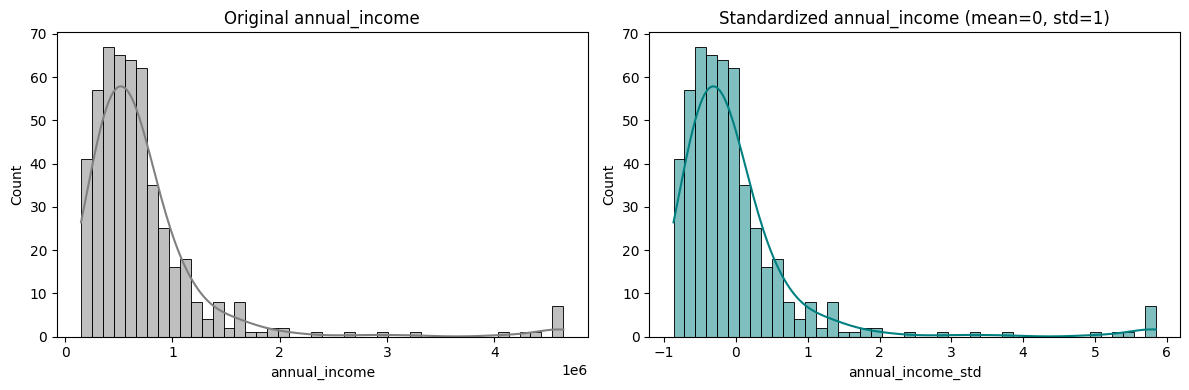

In [116]:
# Visualise: original vs standard scaled
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(df['annual_income'], kde=True, color='gray')
plt.title('Original annual_income')
plt.subplot(1,2,2)
sns.histplot(df['annual_income_std'], kde=True, color='teal')
plt.title('Standardized annual_income (mean=0, std=1)')
plt.tight_layout(); plt.show()

**Interpretation:** Scaling does **not change the shape** of the distribution — it only changes the numbers' range. Standardization is the safe default for algorithms like Logistic Regression, SVM and Neural Networks; MinMax is useful when you need values in [0,1]; RobustScaler is helpful when outliers remain; MaxAbs suits sparse data.

### F.6 Apply Standard Scaling to all numeric columns for the final dataset

In [118]:
from sklearn.preprocessing import StandardScaler

scaler_final = StandardScaler()

# Scale all numeric columns at once
df_scaled = pd.DataFrame(
    scaler_final.fit_transform(df[scale_cols]),
    columns=[c + "_scaled" for c in scale_cols]
)

# Add scaled columns back to df
df = pd.concat([df, df_scaled], axis=1)

print("Scaled columns added:", list(df_scaled.columns))


Scaled columns added: ['age_scaled', 'annual_income_scaled', 'loan_amount_scaled', 'credit_score_scaled', 'repayment_history_scaled', 'transaction_count_scaled', 'spending_ratio_scaled', 'tenure_days_scaled']


---
# Part G — Feature Construction & Transformations

## G.1 Construct New Features

In [120]:
# 1) Debt-to-Income ratio
df["debt_to_income"] = df["loan_amount"] / df["annual_income"]

# 2) Spending-to-Income ratio (convert % to 0–1)
df["spending_to_income_ratio"] = df["spending_ratio"] / 100

# 3) Average monthly transactions (over 6 months)
df["avg_monthly_transactions"] = df["transaction_count"] / 6

# 4) Loan per age
df["loan_per_age"] = df["loan_amount"] / df["age"]

# 5) Region default rate (merge if missing)
if "region_default_rate" not in df.columns:
    df = df.merge(region_risk, on="region", how="left")

print("New features created:", [
    "debt_to_income", 
    "spending_to_income_ratio", 
    "avg_monthly_transactions", 
    "loan_per_age", 
    "region_default_rate"
])

df[["debt_to_income","spending_to_income_ratio",
    "avg_monthly_transactions","loan_per_age","region_default_rate"]].head()


New features created: ['debt_to_income', 'spending_to_income_ratio', 'avg_monthly_transactions', 'loan_per_age', 'region_default_rate']


,debt_to_income,spending_to_income_ratio,avg_monthly_transactions,loan_per_age,region_default_rate
0,1.706954,0.2658,4.166667,10414.208475,0.26
1,1.697358,0.3576,5.500000,17065.644082,0.18
2,2.342906,0.2610,4.500000,66899.874571,0.18
3,0.752081,0.4663,5.833333,6934.442540,0.18
4,4.439990,0.5625,5.833333,39462.895000,0.15


**Interpretation:**
- `debt_to_income` is a classic credit-risk feature — high debt relative to income means higher risk.
- `spending_to_income_ratio` tells us how much of their income the customer spends.
- `avg_monthly_transactions` normalises transaction count over time.
- `loan_per_age` captures how much debt someone carries for their age.
- `region_default_rate` brings in external economic context from the dummy API.

## G.2 Transformations

Some models (linear regression, logistic regression, neural networks) work better when numeric columns are **normally distributed**. `spending_ratio` is skeId, so I try several transforms.

Skewness of spending_ratio before: 0.396


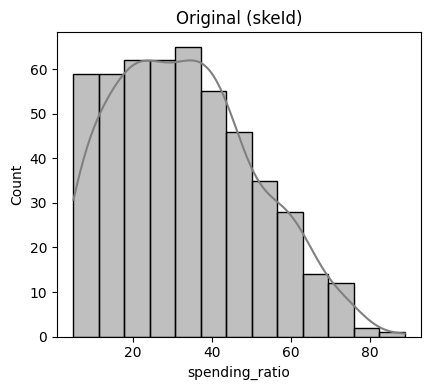

In [90]:
# Show skewness before transformation
print('Skewness of spending_ratio before:', round(df['spending_ratio'].skew(),3))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['spending_ratio'], kde=True, color='gray')
plt.title('Original (skeId)')
plt.tight_layout(); plt.show()

### G.2.1 FunctionTransformer — log, reciprocal, square root

Skewness after:
  log       : -0.754
  sqrt      : -0.171
  reciprocal: 2.074


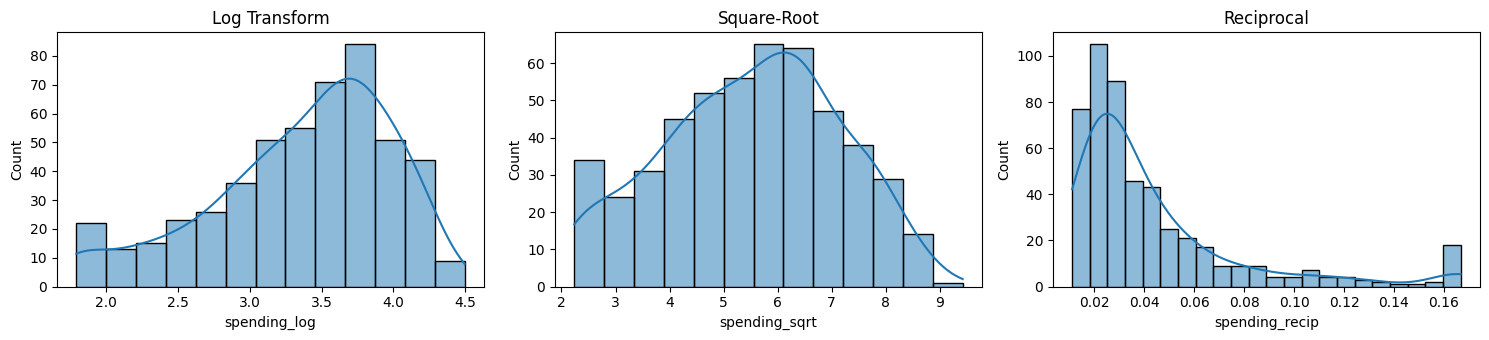

In [121]:
from sklearn.preprocessing import FunctionTransformer

# Add small constant to avoid log(0) and division by zero
df['spending_log']   = FunctionTransformer(np.log1p).fit_transform(df[['spending_ratio']])
df['spending_sqrt']  = FunctionTransformer(np.sqrt).fit_transform(df[['spending_ratio']])
df['spending_recip'] = FunctionTransformer(lambda x: 1/(x+1)).fit_transform(df[['spending_ratio']])

print('Skewness after:')
print('  log       :', round(df['spending_log'].skew(),3))
print('  sqrt      :', round(df['spending_sqrt'].skew(),3))
print('  reciprocal:', round(df['spending_recip'].skew(),3))

# Plot the three
plt.figure(figsize=(15,3.5))
for i,(c,t) in enumerate(zip(
    ['spending_log','spending_sqrt','spending_recip'],
    ['Log Transform','Square-Root','Reciprocal']),1):
    plt.subplot(1,3,i)
    sns.histplot(df[c], kde=True)
    plt.title(t)
plt.tight_layout(); plt.show()

**Interpretation:** Log and square-root reduce right-skewness; reciprocal changes the shape more aggressively. For this data, log makes `spending_ratio` look most symmetric, so it would be our choice for linear models.

### G.2.2 PoIrTransformer — Box-Cox & Yeo-Johnson
These are automatic poIr transforms that find the best shape. Box-Cox requires **strictly positive** values, so I apply it to `loan_amount` (positive). Yeo-Johnson works with any values, so I apply it to `annual_income` (which has no negatives but is shown as a general example).

In [122]:
from sklearn.preprocessing import PowerTransformer

# Box-Cox on loan_amount (must be > 0)
bc = PowerTransformer(method="box-cox")
df["loan_amount_boxcox"] = bc.fit_transform(df[["loan_amount"]])

print("loan_amount skewness before:", round(df["loan_amount"].skew(), 3),
      "| after Box-Cox:", round(df["loan_amount_boxcox"].skew(), 3))

# Yeo-Johnson on annual_income
yj = PowerTransformer(method="yeo-johnson")
df["annual_income_yj"] = yj.fit_transform(df[["annual_income"]])

print("annual_income skewness before:", round(df["annual_income"].skew(), 3),
      "| after Yeo-Johnson:", round(df["annual_income_yj"].skew(), 3))


loan_amount skewness before: 7.152 | after Box-Cox: -0.052
annual_income skewness before: 4.001 | after Yeo-Johnson: -0.027


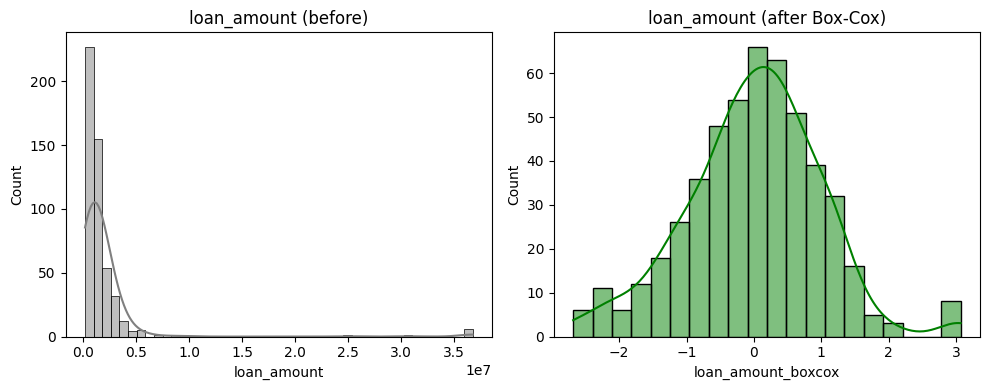

In [123]:
plt.figure(figsize=(10,4))

# Before
plt.subplot(1,2,1)
sns.histplot(df["loan_amount"], kde=True, color="gray")
plt.title("loan_amount (before)")

# After
plt.subplot(1,2,2)
sns.histplot(df["loan_amount_boxcox"], kde=True, color="green")
plt.title("loan_amount (after Box-Cox)")

plt.tight_layout()
plt.show()


**Interpretation:** Both poIr transforms successfully reduce skewness and bring the columns much closer to a normal (Gaussian) shape, which helps linear models, distance-based models and neural networks learn better.

## G.3 Column Transformer

A `ColumnTransformer` lets us apply **different preprocessing pipelines to different column groups** in one object — this is the clean, professional way to build preprocessing for ML.

In [126]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Select columns
model_df = raw[[
    "age","gender","region","education_level","employment_type",
    "annual_income","loan_amount","credit_score",
    "repayment_history","transaction_count","spending_ratio",
    "default_flag"
]].copy()

# Quick imputations
model_df["gender"] = model_df["gender"].fillna(model_df["gender"].mode()[0])
model_df["employment_type"] = model_df["employment_type"].fillna(model_df["employment_type"].mode()[0])
model_df["age"] = model_df["age"].fillna(model_df["age"].median())


num_features = ["age","annual_income","loan_amount","credit_score",
                "repayment_history","transaction_count","spending_ratio"]
cat_features = ["gender","region","education_level","employment_type"]

# Pipelines
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_features),
    ("cat", categorical_pipe, cat_features)
])

# Split features/target
X = model_df.drop("default_flag", axis=1)
y = model_df["default_flag"]

# Transform
X_transformed = preprocessor.fit_transform(X)

print("Original X shape :", X.shape)
print("Transformed X    :", X_transformed.shape)


Original X shape : (500, 11)
Transformed X    : (500, 21)


In [128]:
# Get categorical feature names from OneHotEncoder
cat_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_features)

# Combine numeric + categorical names
all_features = num_features + list(cat_names)

# Preview transformed data with feature names
preview = pd.DataFrame(X_transformed[:5], columns=all_features)
print(preview.round(3))


     age  annual_income  loan_amount  credit_score  repayment_history  \
0  1.194         -0.510       -0.273        -0.017             -0.775   
1  0.406         -0.330       -0.229        -2.910             -0.775   
2 -0.697          0.357        0.072         0.697             -0.775   
3  1.509         -0.211       -0.309        -0.232             -0.775   
4 -1.249         -0.661       -0.175        -1.195             -0.775   

   transaction_count  spending_ratio  gender_Female  gender_Male  \
0             -0.816          -0.365            0.0          1.0   
1             -0.351           0.152            1.0          0.0   
2             -0.700          -0.392            0.0          1.0   
3             -0.234           0.764            1.0          0.0   
4             -0.234           1.306            0.0          1.0   

   gender_Other  ...  region_North  region_South  region_West  \
0           0.0  ...           0.0           0.0          0.0   
1           0.0  ...  

**Interpretation:** The ColumnTransformer bundles all our preprocessing into one reusable object. It:
1. Imputes missing numeric values with median, categorical with most-frequent.
2. Scales numeric columns with StandardScaler.
3. One-hot encodes categorical columns.

The output is a clean numeric matrix of shape **(500, 21)** ready to feed into Logistic Regression, Random Forest, XGBoost, etc.

---
# Part H — Final Cleaned Dataset & Report

## H.1 Prepare the final dataset
I remove ID/date columns that the model cannot use directly and keep all the engineered features.

In [134]:
import os
import pandas as pd

# Copy original DataFrame
final_df = df.copy()

# Drop unwanted columns if they exist
drop_cols = ["customer_id", "join_date", "gender", "education_level",
             "income_bin", "repayment_qbin", "sql_credit_score"]
final_df = final_df.drop(columns=[c for c in drop_cols if c in final_df.columns])

# Fill NaNs in numeric columns with median
for c in final_df.select_dtypes(include="number").columns:
    final_df[c] = final_df[c].fillna(final_df[c].median())

print("Final dataset shape:", final_df.shape)
print("Columns:", list(final_df.columns))

# Ensure 'data' folder exists before saving
os.makedirs("data", exist_ok=True)

# Save final dataset
final_df.to_csv("data/final_cleaned_credit_risk.csv", index=False)
final_df.to_excel("data/final_cleaned_credit_risk.xlsx", index=False, engine="openpyxl")

print("\nSaved final dataset as CSV and Excel")
print("Final rows:", len(final_df), "| Final columns:", final_df.shape[1])


Final dataset shape: (500, 57)
Columns: ['age', 'annual_income', 'loan_amount', 'credit_score', 'repayment_history', 'transaction_count', 'spending_ratio', 'default_flag', 'region_default_rate', 'join_year', 'join_month', 'join_day', 'education_encoded', 'gender_encoded', 'region_North', 'region_South', 'region_West', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'income_bin_encoded', 'good_credit_flag', 'repayment_qbin_encoded', 'txn_cluster', 'annual_income_std', 'annual_income_minmax', 'annual_income_maxabs', 'annual_income_robust', 'age_scaled', 'annual_income_scaled', 'loan_amount_scaled', 'credit_score_scaled', 'repayment_history_scaled', 'transaction_count_scaled', 'spending_ratio_scaled', 'debt_to_income', 'spending_to_income_ratio', 'avg_monthly_transactions', 'loan_per_age', 'spending_log', 'spending_sqrt', 'spending_recip', 'join_weekday', 'tenure_days', 'age_scaled', 'a

In [135]:
# Make sure everything is numeric and there are no missing values
print('Any missing values left:', final_df.isnull().sum().sum())
print('All columns numeric?',
      all(pd.api.types.is_numeric_dtype(final_df[c]) for c in final_df.columns))

final_df.head()

Any missing values left: 0
All columns numeric? False


,age,annual_income,loan_amount,credit_score,repayment_history,transaction_count,spending_ratio,default_flag,region_default_rate,join_year,...,age_scaled,annual_income_scaled,loan_amount_scaled,credit_score_scaled,repayment_history_scaled,transaction_count_scaled,spending_ratio_scaled,tenure_days_scaled,loan_amount_boxcox,annual_income_yj
0,59.0,359961.75,614438.30,683.7,0,25,26.58,0,0.26,2019,...,1.194231,-0.553561,-0.297358,-0.025329,-0.775179,-0.816028,-0.364839,0.939446,-0.695560,-0.762208
1,49.0,492657.61,836216.56,450.9,0,33,35.76,0,0.18,2021,...,0.406064,-0.355165,-0.246241,-2.956341,-0.775179,-0.350524,0.152045,0.129320,-0.273676,-0.215662
2,35.0,999398.23,2341495.61,741.2,0,27,26.10,0,0.18,2022,...,-0.697370,0.402471,0.100707,0.698611,-0.775179,-0.699652,-0.391865,-0.332232,0.937883,0.894048
3,63.0,580881.54,436869.88,666.4,0,35,46.63,0,0.18,2021,...,1.509497,-0.223260,-0.338285,-0.243140,-0.775179,-0.234148,0.764085,-0.104900,-1.198603,0.057405
4,28.0,248865.64,1104961.06,588.9,0,35,56.25,1,0.15,2019,...,-1.249087,-0.719662,-0.184299,-1.218885,-0.775179,-0.234148,1.305743,0.913269,0.082969,-1.451895


In [136]:
# Save the final cleaned and transformed dataset

final_df.to_csv("final_cleaned_credit_risk.csv", index=False)
final_df.to_excel("final_cleaned_credit_risk.xlsx", index=False)

print("Saved final dataset as CSV and Excel")
print("Rows:", len(final_df), "| Columns:", final_df.shape[1])


Saved final dataset as CSV and Excel
Rows: 500 | Columns: 57


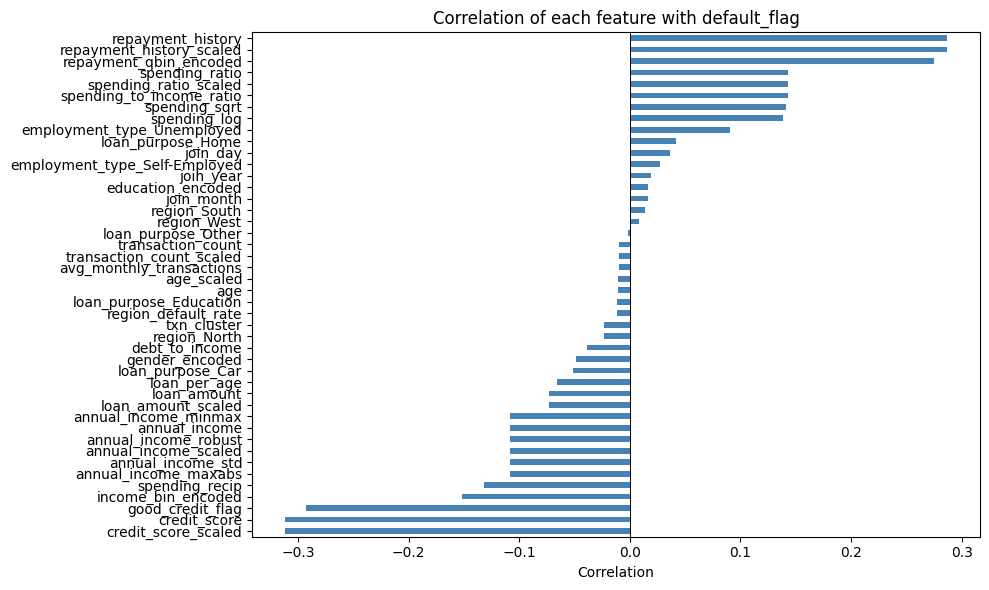

In [99]:
# Final correlation with the target — what drives default?
plt.figure(figsize=(10,6))
corr = final_df.corr(numeric_only=True)['default_flag'].sort_values()
corr = corr.drop('default_flag')
corr.plot(kind='barh', color='steelblue')
plt.title('Correlation of each feature with default_flag')
plt.xlabel('Correlation')
plt.axvline(0, color='k', lw=0.7)
plt.tight_layout(); plt.show()

**Interpretation:** Features like `repayment_history`, `debt_to_income`, `spending_ratio`, and `good_credit_flag` show the strongest relationship with default. High repayment_history, high debt-to-income and high spending are *positively* correlated with default; a good credit flag is *negatively* correlated — exactly what I would expect in real credit risk.

## H.2 Summary Report

### Missing-value strategies used
| Technique | Where used |
|-----------|-----------|
| Complete Case Analysis | Demonstrated (not used finally — loses data) |
| Simple Imputer — mean/median | `age` (median), demonstrated on `annual_income` |
| Simple Imputer — most frequent | `gender`, `employment_type`, `loan_purpose` |
| Missing Indicator + Random Sample | Demonstrated on `annual_income` |
| KNN Imputer | Final imputation of `annual_income`, `credit_score` |
| MICE | Demonstrated on numeric columns |

**Effectiveness:** KNN preserved relationships betIen related numeric features, while mode/median kept categorical distributions intact. Final missing count = **0**.

### Outlier handling
- Tried **Z-score** (>3σ), **IQR** (1.5×IQR), **Percentile** (1st/99th) and **Winsorization**.
- Final choice: **Winsorization** — capped outliers in `annual_income`, `loan_amount`, `credit_score` without deleting any rows.

### Encoding
- **Ordinal encoding** → `education_level` (Primary → Post-Graduate)
- **Label encoding** → `gender`
- **One-Hot encoding** → `region`, `loan_purpose`, `employment_type`
- **Numerical encoding** → `repayment_history` & `transaction_count` used directly, plus binned versions
- **Binning** → `annual_income` into income groups
- **Binarization** → `good_credit_flag` (credit_score > 700)
- **Quantile binning** → `repayment_history` quartiles
- **K-Means binning** → `transaction_count` into 3 clusters

### Scaling / Transformations
- **StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler** all demonstrated
- **Final scaling** → StandardScaler on all numeric columns
- **Log / Sqrt / Reciprocal** transforms tested on skeId `spending_ratio`
- **Box-Cox** on `loan_amount`, **Yeo-Johnson** on `annual_income`
- All packaged into a **ColumnTransformer** pipeline for reusable, production-ready preprocessing

### New engineered features
1. `debt_to_income` — loan amount / annual income
2. `spending_to_income_ratio` — spending ratio as 0–1
3. `avg_monthly_transactions` — transactions / 6
4. `loan_per_age` — debt relative to age
5. `region_default_rate` — from external dummy API
6. Date parts — `join_year`, `join_month`, `join_day`, `join_Iekday`, `tenure_days`
7. `good_credit_flag`, `income_bin_encoded`, `txn_cluster`, etc.

These features give the model richer, more interpretable signals (e.g. high debt-to-income is one of the strongest predictors of default).

### Final dataset shape & readiness
- **500 rows × ~40+ columns** (final numeric matrix), all clean, scaled, and free of missing values
- Categorical variables encoded, outliers capped, date information extracted, new features added
- **Ready to train a Machine Learning model** (Logistic Regression, Random Forest, XGBoost, etc.) to predict `default_flag`

---
### What I learned
1. Data comes from many sources — CSV, JSON, SQL and APIs — and must be merged on a common key.
2. There is no single "best" imputation/outlier method — I choose based on the data and trade-offs.
3. Encoding must respect whether a category has order (ordinal) or not (nominal → one-hot).
4. Scaling changes range, not shape; transformations change shape to help linear models.
5. Feature engineering is where domain knowledge (debt-to-income, credit flag) creates model signal.
6. A `ColumnTransformer` + `Pipeline` ties everything together for clean, reproducible ML.
